# Meaningful vs Vanity Engagement in EdTech

В этом проекте я хочу посмотреть, какие признаки вовлеченности в edtech реально связаны с успешным результатом, а какие только создают видимость активности.

Идея довольно простая: если пользователь много кликает, это еще не значит, что он действительно продвигается по курсу. Поэтому я хочу сравнить две группы метрик:

- метрики объема активности;
- метрики, которые больше похожи на осмысленный прогресс.

Мне интересно, что лучше объясняет итоговый результат: просто интенсивность использования или более содержательные действия вроде попыток assessment и качества результата.

### Загрузка данных и первая проверка

Сначала просто проверяю, что датасет читается нормально и с ним вообще удобно работать. Здесь важно понять несколько базовых вещей:

- нет ли пропусков и дублей;
- как распределен `final_result`;
- нет ли совсем странных значений в ключевых колонках.

Это скорее технический шаг, но без него дальше идти бессмысленно.

Shape: (32593, 21)

Columns:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'total_clicks', 'active_days', 'unique_resources', 'num_forum', 'num_quiz', 'avg_score', 'num_assess_attempted', 'total_weight', 'module_presentation_length']

Filtered shape: (32593, 21)


,code_module,code_presentation,id_student,final_result,total_clicks,active_days,unique_resources,num_forum,num_quiz,avg_score,num_assess_attempted,total_weight,module_presentation_length,num_of_prev_attempts,studied_credits,highest_education,age_band,imd_band,disability,gender,region
0,AAA,2013J,11391,Pass,934.000,40.000,55.000,0.000,0.000,82.000,5.000,100.000,268,0,240,HE Qualification,55<=,90-100%,N,M,East Anglian Region
1,AAA,2013J,28400,Pass,"1,435.000",80.000,84.000,0.000,0.000,66.400,5.000,100.000,268,0,60,HE Qualification,35-55,20-30%,N,F,Scotland
2,AAA,2013J,30268,Withdrawn,281.000,12.000,22.000,0.000,0.000,0.000,0.000,0.000,268,0,60,A Level or Equivalent,35-55,30-40%,Y,F,North Western Region
3,AAA,2013J,31604,Pass,"2,158.000",123.000,82.000,0.000,0.000,76.000,5.000,100.000,268,0,60,A Level or Equivalent,35-55,50-60%,N,F,South East Region
4,AAA,2013J,32885,Pass,"1,034.000",70.000,66.000,0.000,0.000,54.400,5.000,100.000,268,0,60,Lower Than A Level,0-35,50-60%,N,F,West Midlands Region


,dtype
code_module,str
code_presentation,str
id_student,int64
final_result,str
total_clicks,float64
active_days,float64
unique_resources,float64
num_forum,float64
num_quiz,float64
avg_score,float64



Missing values:


,n_missing,share_missing
code_module,0,0.000
code_presentation,0,0.000
id_student,0,0.000
final_result,0,0.000
total_clicks,0,0.000
active_days,0,0.000
unique_resources,0,0.000
num_forum,0,0.000
num_quiz,0,0.000
avg_score,0,0.000



Duplicates by (id_student, code_module, code_presentation): 0

final_result distribution:


,count,share
final_result,,
Pass,12361,0.379
Withdrawn,10156,0.312
Fail,7052,0.216
Distinction,3024,0.093


,count,mean,std,min,25%,50%,75%,max
id_student,"32,593.000","706,687.669","549,167.314","3,733.000","508,573.000","590,310.000","644,453.000","2,716,795.000"
total_clicks,"32,593.000","1,215.141","1,692.604",0.000,142.000,602.000,"1,585.000","24,139.000"
active_days,"32,593.000",55.476,54.515,0.000,11.000,40.000,85.000,286.000
unique_resources,"32,593.000",60.151,55.899,0.000,19.000,46.000,86.000,413.000
num_forum,"32,593.000",0.000,0.000,0.000,0.000,0.000,0.000,0.000
num_quiz,"32,593.000",28.060,47.054,0.000,0.000,10.000,38.000,968.000
avg_score,"32,593.000",57.647,32.927,0.000,43.000,70.571,82.400,100.000
num_assess_attempted,"32,593.000",5.331,4.326,0.000,1.000,5.000,9.000,14.000
total_weight,"32,593.000",68.000,66.134,0.000,0.000,70.000,100.000,200.000
module_presentation_length,"32,593.000",256.010,13.179,234.000,241.000,262.000,268.000,269.000


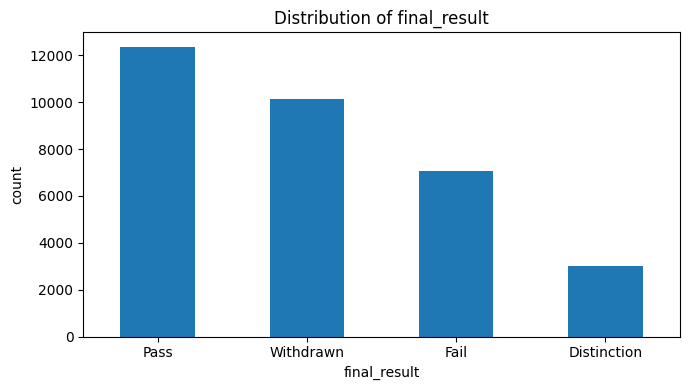

Saved:
- outputs/figures/final_result_distribution.png
- outputs/tables/base_filtered.csv


In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DATA_PATH = Path("final_dataset.csv")

OUTPUTS_DIR = Path("outputs")
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")

def save_table(df_to_save: pd.DataFrame, filename: str, index: bool = False) -> None:
    df_to_save.to_csv(TABLES_DIR / filename, index=index)

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

ID_COLS = [
    "code_module",
    "code_presentation",
    "id_student"
]

TARGET_COLS = [
    "final_result"
]

BEHAVIOR_COLS = [
    "total_clicks",
    "active_days",
    "unique_resources",
    "num_forum",
    "num_quiz",
    "avg_score",
    "num_assess_attempted",
    "total_weight",
    "module_presentation_length"
]

CONTROL_COLS = [
    "num_of_prev_attempts",
    "studied_credits",
    "highest_education",
    "age_band",
    "imd_band",
    "disability",
    "gender",
    "region"
]

KEEP_COLS_EXTENDED = ID_COLS + TARGET_COLS + BEHAVIOR_COLS + CONTROL_COLS
df = df[KEEP_COLS_EXTENDED].copy()

print("\nFiltered shape:", df.shape)

display(df.head())
display(df.dtypes.to_frame("dtype"))

missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("n_missing")
)
missing["share_missing"] = missing["n_missing"] / len(df)

print("\nMissing values:")
display(missing)

dup_mask = df.duplicated(subset=["id_student", "code_module", "code_presentation"])
print(f"\nDuplicates by (id_student, code_module, code_presentation): {dup_mask.sum()}")

result_counts = df["final_result"].value_counts(dropna=False).to_frame("count")
result_counts["share"] = result_counts["count"] / len(df)

print("\nfinal_result distribution:")
display(result_counts)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
display(df[numeric_cols].describe().T)

plt.figure(figsize=(7, 4))
df["final_result"].value_counts().plot(kind="bar")
plt.title("Distribution of final_result")
plt.xlabel("final_result")
plt.ylabel("count")
plt.xticks(rotation=0)
save_fig("final_result_distribution.png")
plt.show()

save_table(df, "base_filtered.csv", index=False)
print("Saved:")
print("- outputs/figures/final_result_distribution.png")
print("- outputs/tables/base_filtered.csv")

## Подготовка признаков

Теперь из исходных колонок хочу собрать более удобные признаки для анализа.

Сырые агрегаты сами по себе не всегда хорошо читаются, поэтому здесь я делаю несколько производных метрик. В первую очередь меня интересуют три типа сигналов:

- общий объем активности;
- признаки, которые больше похожи на реальный прогресс;
- относительные метрики, которые могут показать, насколько поведение пользователя было поверхностным или, наоборот, более осмысленным.

Заодно сразу делаю бинарные таргеты для успеха и для withdrawal, чтобы потом было проще сравнивать результаты.

In [16]:
# Block 2. Target creation  + Feature engineering

if "num_forum" in df.columns:
    df = df.drop(columns=["num_forum"])

# Бинарные таргеты
df["success_flag"] = df["final_result"].isin(["Pass", "Distinction"]).astype(int)
df["withdraw_flag"] = (df["final_result"] == "Withdrawn").astype(int)
df["fail_flag"] = (df["final_result"] == "Fail").astype(int)
df["distinction_flag"] = (df["final_result"] == "Distinction").astype(int)

# Безопасные делители
safe_active_days = df["active_days"].replace(0, np.nan)
safe_total_clicks = df["total_clicks"].replace(0, np.nan)
safe_module_len = df["module_presentation_length"].replace(0, np.nan)
safe_unique_resources = df["unique_resources"].replace(0, np.nan)

# Базовые инженерные признаки
df["clicks_per_day"] = df["total_clicks"] / safe_active_days
df["resources_per_day"] = df["unique_resources"] / safe_active_days
df["assessments_per_day"] = df["num_assess_attempted"] / safe_active_days

df["quiz_share"] = df["num_quiz"] / safe_total_clicks
df["engagement_breadth"] = df["unique_resources"] / safe_total_clicks
df["engagement_intensity"] = df["total_clicks"] / safe_module_len
df["assessment_density"] = df["num_assess_attempted"] / safe_module_len

df["resource_efficiency"] = df["avg_score"] / safe_unique_resources
df["click_efficiency"] = df["avg_score"] / safe_total_clicks
df["log_total_clicks"] = np.log1p(df["total_clicks"])

#Служебные флаги
df["no_activity_flag"] = ((df["active_days"] == 0) | (df["total_clicks"] == 0)).astype(int)
df["no_assessment_flag"] = (df["num_assess_attempted"] == 0).astype(int)

EDA_NUMERIC_COLS = [
    "total_clicks",
    "log_total_clicks",
    "active_days",
    "unique_resources",
    "num_quiz",
    "avg_score",
    "num_assess_attempted",
    "total_weight",
    "clicks_per_day",
    "resources_per_day",
    "assessments_per_day",
    "quiz_share",
    "engagement_breadth",
    "engagement_intensity",
    "assessment_density",
    "resource_efficiency",
    "click_efficiency"
]

new_cols = [
    "success_flag",
    "withdraw_flag",
    "fail_flag",
    "distinction_flag",
    "clicks_per_day",
    "resources_per_day",
    "assessments_per_day",
    "quiz_share",
    "engagement_breadth",
    "engagement_intensity",
    "assessment_density",
    "resource_efficiency",
    "click_efficiency",
    "log_total_clicks",
    "no_activity_flag",
    "no_assessment_flag"
]

print("Created columns:")
print(new_cols)

display(df[new_cols].head())

print("\nMissing values in engineered features:")
display(df[new_cols].isna().sum().to_frame("n_missing"))

print("\nShares of inactivity / no assessment:")
display(df[["no_activity_flag", "no_assessment_flag"]].mean().to_frame("share"))

df.to_csv("feature_table.csv", index=False)
print("Saved: feature_table.csv")

Created columns:
['success_flag', 'withdraw_flag', 'fail_flag', 'distinction_flag', 'clicks_per_day', 'resources_per_day', 'assessments_per_day', 'quiz_share', 'engagement_breadth', 'engagement_intensity', 'assessment_density', 'resource_efficiency', 'click_efficiency', 'log_total_clicks', 'no_activity_flag', 'no_assessment_flag']


,success_flag,withdraw_flag,fail_flag,distinction_flag,clicks_per_day,resources_per_day,assessments_per_day,quiz_share,engagement_breadth,engagement_intensity,assessment_density,resource_efficiency,click_efficiency,log_total_clicks,no_activity_flag,no_assessment_flag
0,1,0,0,0,23.350,1.375,0.125,0.000,0.059,3.485,0.019,1.491,0.088,6.841,0,0
1,1,0,0,0,17.938,1.050,0.062,0.000,0.059,5.354,0.019,0.790,0.046,7.270,0,0
2,0,1,0,0,23.417,1.833,0.000,0.000,0.078,1.049,0.000,0.000,0.000,5.642,0,1
3,1,0,0,0,17.545,0.667,0.041,0.000,0.038,8.052,0.019,0.927,0.035,7.677,0,0
4,1,0,0,0,14.771,0.943,0.071,0.000,0.064,3.858,0.019,0.824,0.053,6.942,0,0



Missing values in engineered features:


,n_missing
success_flag,0
withdraw_flag,0
fail_flag,0
distinction_flag,0
clicks_per_day,3365
resources_per_day,3365
assessments_per_day,3365
quiz_share,3365
engagement_breadth,3365
engagement_intensity,0



Shares of inactivity / no assessment:


,share
no_activity_flag,0.103
no_assessment_flag,0.208


Saved: feature_table.csv


## Первичный разбор по итоговому результату

Перед тем как сравнивать разные рамки вовлеченности, сначала хочу просто посмотреть на данные в лоб.

Здесь мне важно понять, чем в среднем отличаются:
- успешные пользователи;
- неуспешные;
- те, кто withdrew.

На этом шаге я не пытаюсь ничего “доказывать”, а просто ищу первые паттерны: какие признаки реально разделяют группы, а какие выглядят не очень полезными.

Median summary by final_result:


,total_clicks,log_total_clicks,active_days,unique_resources,num_quiz,avg_score,num_assess_attempted,total_weight,clicks_per_day,resources_per_day,assessments_per_day,quiz_share,engagement_breadth,engagement_intensity,assessment_density,resource_efficiency,click_efficiency
final_result,,,,,,,,,,,,,,,,,
Distinction,"1,896.000",7.548,103.000,82.000,40.000,89.417,9.000,100.000,19.358,0.944,0.083,0.023,0.047,7.309,0.034,1.089,0.047
Fail,317.000,5.762,22.000,32.000,3.000,61.000,3.000,25.000,14.640,1.464,0.111,0.013,0.103,1.251,0.011,1.290,0.106
Pass,"1,343.000",7.203,78.000,73.000,33.000,77.857,9.000,100.000,17.825,1.063,0.106,0.022,0.056,5.225,0.034,0.992,0.056
Withdrawn,89.000,4.500,7.000,14.000,0.000,0.000,0.000,0.000,14.443,1.667,0.056,0.004,0.124,0.347,0.000,0.927,0.068



Mean summary by final_result:


,total_clicks,log_total_clicks,active_days,unique_resources,num_quiz,avg_score,num_assess_attempted,total_weight,clicks_per_day,resources_per_day,assessments_per_day,quiz_share,engagement_breadth,engagement_intensity,assessment_density,resource_efficiency,click_efficiency
final_result,,,,,,,,,,,,,,,,,
Distinction,"2,666.759",7.505,110.043,102.447,65.178,88.493,8.707,112.365,21.942,1.013,0.116,0.035,0.056,10.361,0.034,1.268,0.074
Fail,651.853,5.369,33.177,43.078,15.885,52.508,4.027,49.196,17.206,1.801,0.175,0.030,0.144,2.568,0.016,2.411,0.495
Pass,"1,921.809",7.158,87.044,89.055,43.660,76.160,8.574,113.609,20.470,1.152,0.152,0.034,0.068,7.493,0.034,1.285,0.099
Withdrawn,313.950,3.637,16.289,24.232,6.477,29.496,1.282,12.335,17.068,2.181,0.087,0.023,0.182,1.231,0.005,1.652,0.259



Flag summary by final_result:


...


Success vs non-success median differences:


,non_success_median,success_median,abs_diff,ratio_success_to_non_success
total_clicks,175.000,"1,425.000","1,250.000",8.143
total_weight,7.000,100.000,93.000,14.286
active_days,12.000,82.000,70.000,6.833
unique_resources,22.000,75.000,53.000,3.409
num_quiz,0.000,34.000,34.000,NaN
avg_score,47.845,80.273,32.427,1.678
num_assess_attempted,1.000,9.000,8.000,9.000
engagement_intensity,0.686,5.556,4.870,8.101
clicks_per_day,14.531,18.138,3.607,1.248
log_total_clicks,5.170,7.263,2.092,1.405



Withdrawn vs not-withdrawn median differences:


,not_withdrawn_median,withdrawn_median,abs_diff,ratio_withdrawn_to_not
total_clicks,999.000,89.000,-910.000,0.089
total_weight,100.000,0.000,-100.000,0.000
avg_score,76.273,0.000,-76.273,0.000
active_days,62.000,7.000,-55.000,0.113
unique_resources,60.000,14.000,-46.000,0.233
num_quiz,25.000,0.000,-25.000,0.000
num_assess_attempted,7.000,0.000,-7.000,0.000
engagement_intensity,3.921,0.347,-3.574,0.089
clicks_per_day,17.035,14.443,-2.592,0.848
log_total_clicks,6.908,4.500,-2.408,0.651


<Figure size 700x400 with 0 Axes>

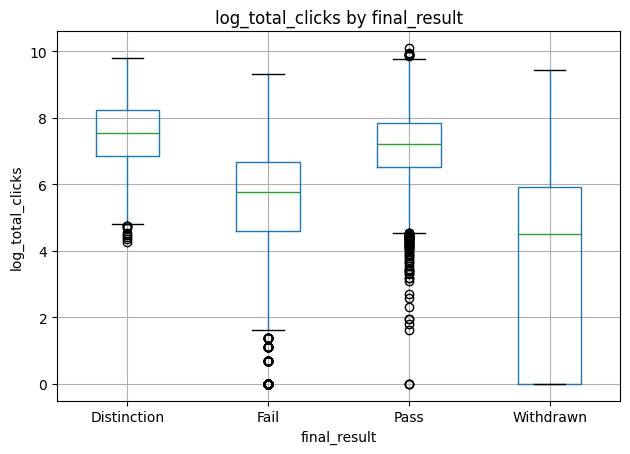

<Figure size 700x400 with 0 Axes>

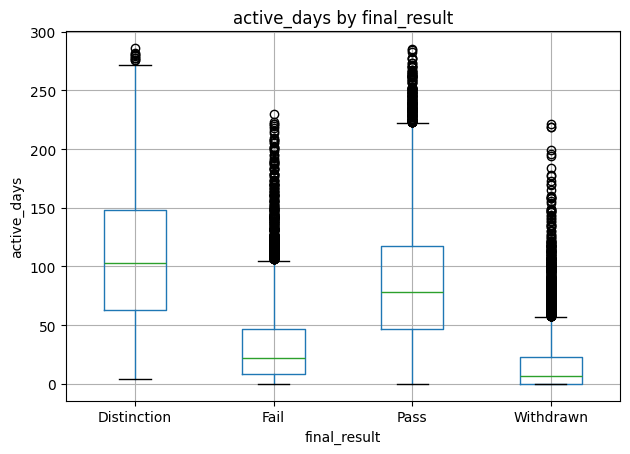

<Figure size 700x400 with 0 Axes>

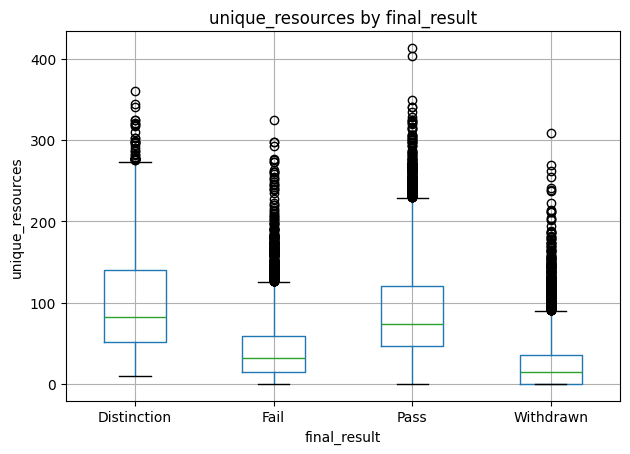

<Figure size 700x400 with 0 Axes>

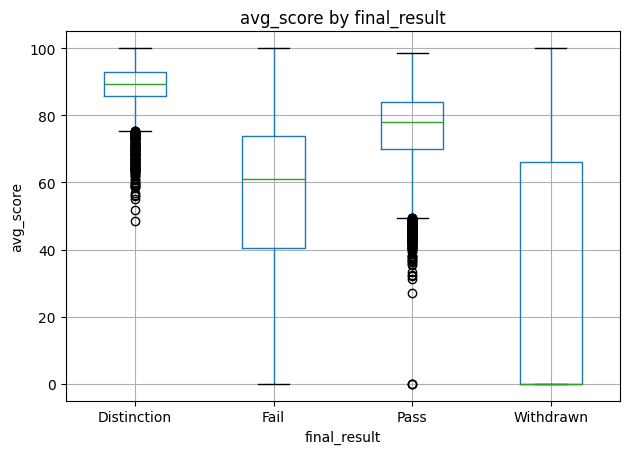

<Figure size 700x400 with 0 Axes>

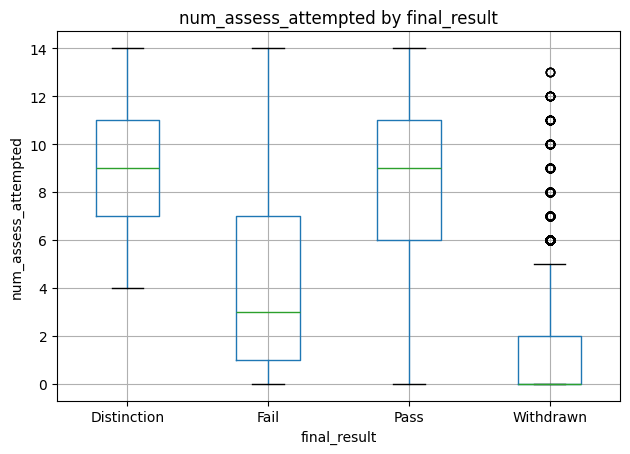

<Figure size 700x400 with 0 Axes>

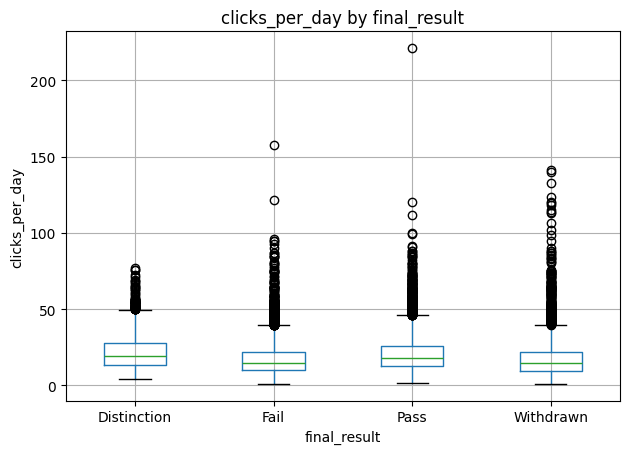

<Figure size 700x400 with 0 Axes>

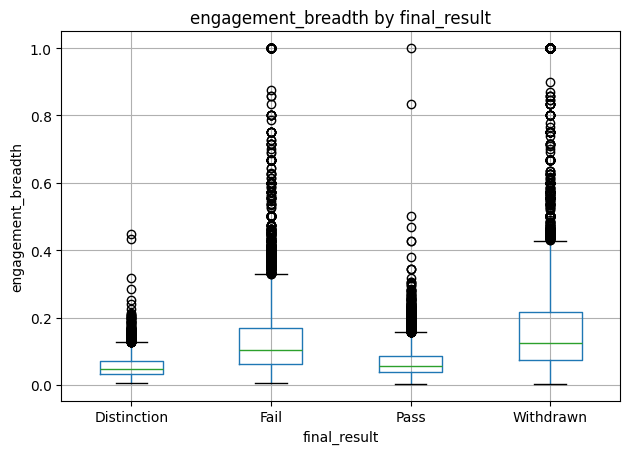

<Figure size 700x400 with 0 Axes>

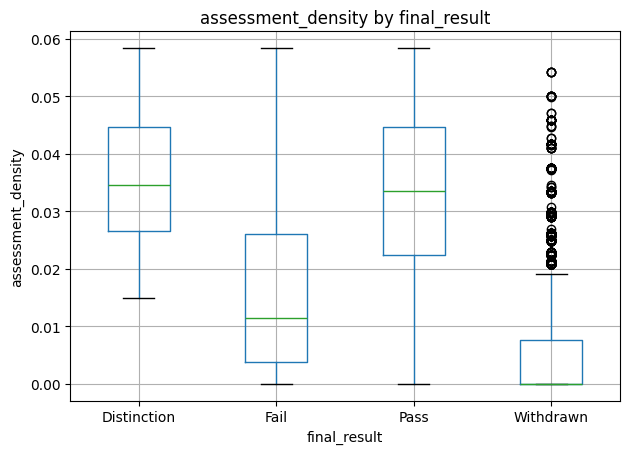

In [17]:
#Block 3. Eda by Outcome

summary_median = (
    df.groupby("final_result")[EDA_NUMERIC_COLS]
      .median()
      .round(3)
)

summary_mean = (
    df.groupby("final_result")[EDA_NUMERIC_COLS]
      .mean()
      .round(3)
)

flag_summary = (
    df.groupby("final_result")[["no_activity_flag", "no_assessment_flag", "success_flag", "withdraw_flag"]]
      .mean()
      .round(3)
)

success_compare = (
    df.groupby("success_flag")[EDA_NUMERIC_COLS]
      .median()
      .round(3)
)

withdraw_compare = (
    df.groupby("withdraw_flag")[EDA_NUMERIC_COLS]
      .median()
      .round(3)
)

print("Median summary by final_result:")
display(summary_median)

print("\nMean summary by final_result:")
display(summary_mean)

print("\nFlag summary by final_result:")
display(flag_summary)

print("\nMedian summary by success_flag:")
display(success_compare)

print("\nMedian summary by withdraw_flag:")
display(withdraw_compare)

median_diff_success = (
    df.groupby("success_flag")[EDA_NUMERIC_COLS]
      .median()
      .T
)
median_diff_success.columns = ["non_success_median", "success_median"]
median_diff_success["abs_diff"] = (
    median_diff_success["success_median"] - median_diff_success["non_success_median"]
).round(3)
median_diff_success["ratio_success_to_non_success"] = (
    median_diff_success["success_median"] / median_diff_success["non_success_median"].replace(0, np.nan)
).round(3)

median_diff_withdraw = (
    df.groupby("withdraw_flag")[EDA_NUMERIC_COLS]
      .median()
      .T
)
median_diff_withdraw.columns = ["not_withdrawn_median", "withdrawn_median"]
median_diff_withdraw["abs_diff"] = (
    median_diff_withdraw["withdrawn_median"] - median_diff_withdraw["not_withdrawn_median"]
).round(3)
median_diff_withdraw["ratio_withdrawn_to_not"] = (
    median_diff_withdraw["withdrawn_median"] / median_diff_withdraw["not_withdrawn_median"].replace(0, np.nan)
).round(3)

print("\nSuccess vs non-success median differences:")
display(median_diff_success.sort_values("abs_diff", ascending=False))

print("\nWithdrawn vs not-withdrawn median differences:")
display(median_diff_withdraw.sort_values("abs_diff"))

plot_cols = [
    "log_total_clicks",
    "active_days",
    "unique_resources",
    "avg_score",
    "num_assess_attempted",
    "clicks_per_day",
    "engagement_breadth",
    "assessment_density"
]

for col in plot_cols:
    plt.figure(figsize=(7, 4))
    df.boxplot(column=col, by="final_result")
    plt.title(f"{col} by final_result")
    plt.suptitle("")
    plt.xlabel("final_result")
    plt.ylabel(col)
    plt.xticks(rotation=0)
    save_fig(f"boxplot_{col}_by_result.png")
    plt.show()

summary_median.to_csv("eda_summary_median_by_result.csv")
median_diff_success.to_csv("eda_success_median_diff.csv")
median_diff_withdraw.to_csv("eda_withdraw_median_diff.csv")

### Что уже видно после первого разбора

Уже на этом этапе видно, что простая активность важна, но этого недостаточно.

С одной стороны, успешные пользователи действительно в среднем активнее. С другой стороны, самые сильные различия, похоже, связаны не просто с числом кликов, а с более содержательными вещами — например, с assessment-related активностью и score.

Это хороший момент, потому что именно отсюда появляется главный вопрос проекта: где проходит граница между просто активностью и осмысленной вовлеченностью.

## Meaningful engagement vs vanity engagement

Теперь хочу сравнить метрики уже более предметно.

Здесь логика такая: часть признаков выглядит как обычные метрики активности — например, клики, дни активности, общая интенсивность. Но есть и другая группа признаков, которые больше похожи на реальные сигналы прогресса.

Моя гипотеза в том, что progress-oriented метрики будут лучше разделять успех и withdrawal, чем просто usage volume.

Quartile comparison table:


,metric,bucket,n_users,success_rate,withdraw_rate
0,total_clicks,Q1,8150,0.022,0.708
1,total_clicks,Q2,8154,0.345,0.338
2,total_clicks,Q3,8144,0.660,0.153
3,total_clicks,Q4,8145,0.861,0.046
4,log_total_clicks,Q1,8150,0.022,0.708
5,log_total_clicks,Q2,8154,0.345,0.338
6,log_total_clicks,Q3,8144,0.660,0.153
7,log_total_clicks,Q4,8145,0.861,0.046
8,active_days,Q1,8524,0.020,0.707
9,active_days,Q2,7973,0.315,0.357


Metric strength ranking:


,metric,success_rate_Q1,success_rate_Q2,success_rate_Q3,success_rate_Q4,withdraw_rate_Q1,withdraw_rate_Q2,withdraw_rate_Q3,withdraw_rate_Q4,success_lift_last_vs_first,withdraw_reduction_first_vs_last,combined_signal_strength
1,assessment_density,0.001,0.290,0.740,0.880,0.776,0.375,0.069,0.009,0.879,0.767,1.646
7,num_assess_attempted,0.001,0.407,0.758,0.886,0.752,0.301,0.052,0.008,0.885,0.744,1.629
0,active_days,0.020,0.315,0.678,0.898,0.707,0.357,0.135,0.026,0.879,0.681,1.560
10,total_clicks,0.022,0.345,0.660,0.861,0.708,0.338,0.153,0.046,0.840,0.662,1.502
6,log_total_clicks,0.022,0.345,0.660,0.861,0.708,0.338,0.153,0.046,0.840,0.662,1.502
5,engagement_intensity,0.021,0.345,0.664,0.858,0.709,0.338,0.152,0.048,0.837,0.662,1.499
2,avg_score,0.006,0.405,0.681,0.798,0.763,0.229,0.143,0.110,0.792,0.653,1.445
12,unique_resources,0.030,0.406,0.647,0.822,0.700,0.306,0.164,0.063,0.792,0.637,1.429
3,clicks_per_day,0.371,0.529,0.570,0.635,0.332,0.240,0.222,0.188,0.265,0.144,0.409
9,resources_per_day,0.744,0.614,0.522,0.225,0.113,0.184,0.233,0.451,-0.519,-0.338,-0.857


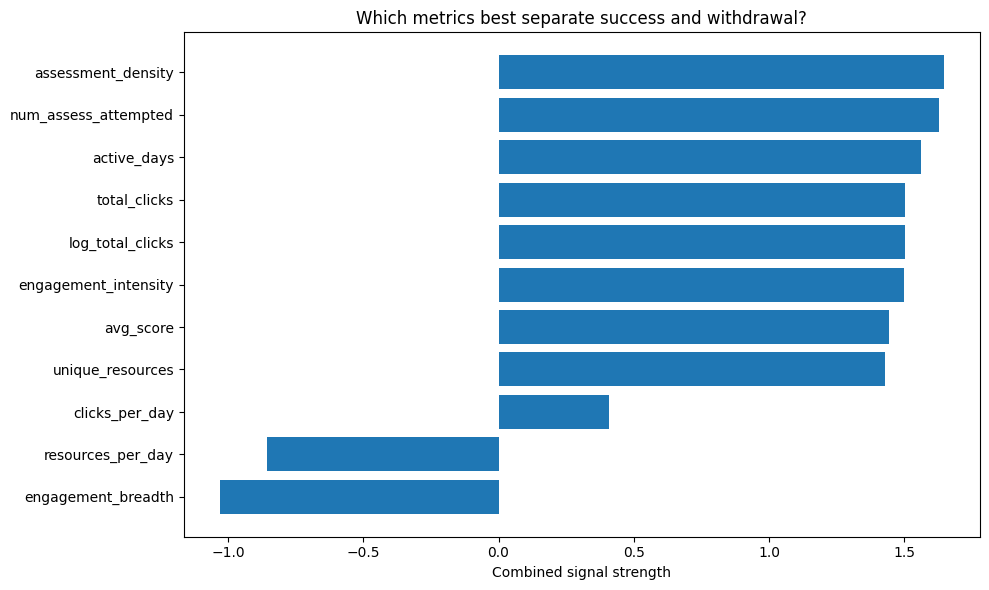

Saved:
- quartile_metric_comparison.csv
- metric_strength_ranking.csv


In [18]:
#Block 4. Meaningful vs. Vanity Engagement

VANITY_METRICS = [
    "total_clicks",
    "log_total_clicks",
    "active_days",
    "clicks_per_day",
    "engagement_intensity"
]

MEANINGFUL_METRICS_BEHAVIOR = [
    "unique_resources",
    "num_quiz",
    "resources_per_day",
    "engagement_breadth"
]

MEANINGFUL_METRICS_PROGRESS = [
    "avg_score",
    "num_assess_attempted",
    "assessment_density",
    "total_weight"
]

ALL_COMPARE_METRICS = (
    VANITY_METRICS
    + MEANINGFUL_METRICS_BEHAVIOR
    + MEANINGFUL_METRICS_PROGRESS
)

def quartile_lift_table(data, metric, target_col="success_flag"):
    temp = data[[metric, target_col, "withdraw_flag"]].dropna().copy()

    # если у признака слишком мало уникальных значений, делить бессмысленно
    if temp[metric].nunique() < 2:
        return None

    try:
        # режем без labels, чтобы не ловить ошибку из-за duplicates="drop"
        temp["bucket_raw"] = pd.qcut(temp[metric], q=4, duplicates="drop")
    except Exception:
        return None

    #сколько корзин реально получилось
    bucket_categories = temp["bucket_raw"].cat.categories
    n_bins = len(bucket_categories)

    if n_bins < 2:
        return None

   
    label_map = {cat: f"Q{i+1}" for i, cat in enumerate(bucket_categories)}
    temp["bucket"] = temp["bucket_raw"].map(label_map)

    out = (
        temp.groupby("bucket", observed=False)[[target_col, "withdraw_flag"]]
            .mean()
            .rename(columns={
                target_col: "success_rate",
                "withdraw_flag": "withdraw_rate"
            })
    )

    out["n_users"] = temp.groupby("bucket", observed=False).size()
    out = out.reset_index()

    # сортируем Q1, Q2, Q3, ...
    out["bucket_num"] = out["bucket"].str.extract(r"(\d+)").astype(int)
    out = out.sort_values("bucket_num").drop(columns="bucket_num")

    # только теперь добавляем metric
    out["metric"] = metric

    return out[["metric", "bucket", "n_users", "success_rate", "withdraw_rate"]]

quartile_tables = []

for metric in ALL_COMPARE_METRICS:
    qt = quartile_lift_table(df, metric, target_col="success_flag")
    if qt is not None:
        quartile_tables.append(qt)

quartile_results = pd.concat(quartile_tables, ignore_index=True)

print("Quartile comparison table:")
display(quartile_results.head(20))

metric_strength = (
    quartile_results
    .pivot(index="metric", columns="bucket", values=["success_rate", "withdraw_rate"])
)

metric_strength.columns = [f"{a}_{b}" for a, b in metric_strength.columns]
metric_strength = metric_strength.reset_index()

success_cols = sorted([c for c in metric_strength.columns if c.startswith("success_rate_Q")])
withdraw_cols = sorted([c for c in metric_strength.columns if c.startswith("withdraw_rate_Q")])

metric_strength["success_lift_last_vs_first"] = (
    metric_strength[success_cols[-1]] - metric_strength[success_cols[0]]
).round(3)

metric_strength["withdraw_reduction_first_vs_last"] = (
    metric_strength[withdraw_cols[0]] - metric_strength[withdraw_cols[-1]]
).round(3)

metric_strength["combined_signal_strength"] = (
    metric_strength["success_lift_last_vs_first"] +
    metric_strength["withdraw_reduction_first_vs_last"]
).round(3)

metric_strength = metric_strength.sort_values("combined_signal_strength", ascending=False)

print("Metric strength ranking:")
display(metric_strength)

plt.figure(figsize=(10, 6))
plt.barh(metric_strength["metric"], metric_strength["combined_signal_strength"])
plt.title("Which metrics best separate success and withdrawal?")
plt.xlabel("Combined signal strength")
plt.gca().invert_yaxis()
save_fig("metric_strength_ranking.png")
plt.show()

quartile_results.to_csv("quartile_metric_comparison.csv", index=False)
metric_strength.to_csv("metric_strength_ranking.csv", index=False)

print("Saved:")
print("- quartile_metric_comparison.csv")
print("- metric_strength_ranking.csv")

## Сегментация пользователей: volume vs progress

После сравнения отдельных метрик хочу перейти к более продуктовой картинке.

Отдельные признаки — это полезно, но для итогового вывода удобнее собрать пользователей в несколько понятных сегментов. Поэтому дальше я раскладываю их по двум осям:

- насколько у них высокий объем активности;
- насколько у них высокий прогресс.

В идеале это должно показать, что “много активности” и “хорошая вовлеченность” — не одно и то же.

,n_users,success_rate,withdraw_rate,median_clicks,median_active_days,median_avg_score,median_assess
engagement_segment,,,,,,,
High volume / High progress,13164,0.859,0.035,"1,791.000",94.000,80.875,9.000
Low volume / High progress,3133,0.716,0.053,362.000,29.000,77.571,9.000
High volume / Low progress,3133,0.433,0.310,"1,126.000",59.000,67.000,4.000
Low volume / Low progress,13163,0.037,0.650,84.000,7.000,0.000,0.000


final_result,Distinction,Fail,Pass,Withdrawn
engagement_segment,,,,
High volume / High progress,0.201,0.106,0.658,0.035
High volume / Low progress,0.015,0.257,0.418,0.310
Low volume / High progress,0.103,0.231,0.613,0.053
Low volume / Low progress,0.001,0.314,0.036,0.650


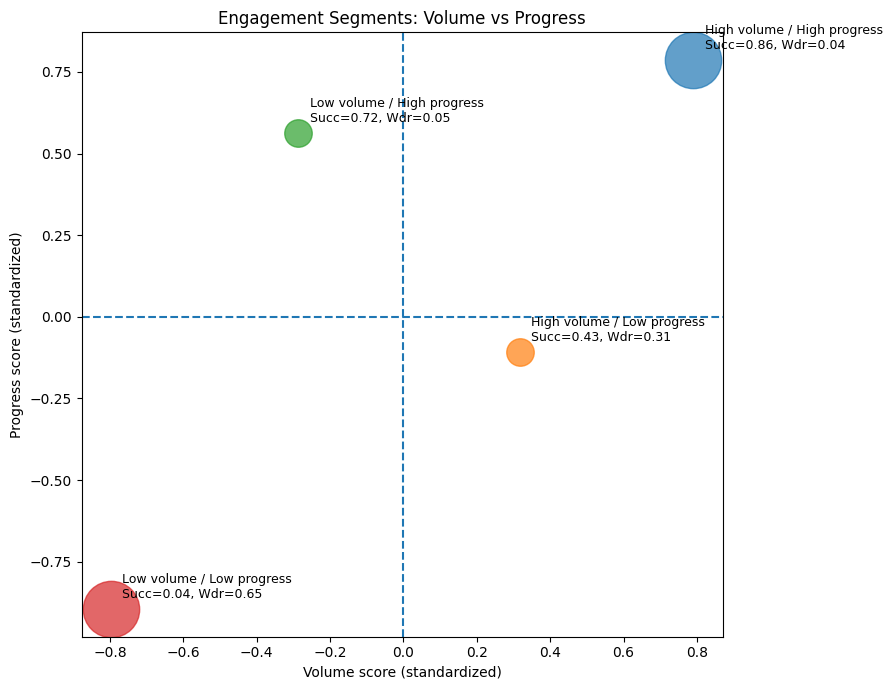

In [19]:
#Block 5. User Segmentation: Volume VS Progress

def zscore(s):
    return (s - s.mean()) / s.std()

df["volume_score"] = (
    0.40 * zscore(df["log_total_clicks"]) +
    0.35 * zscore(df["active_days"]) +
    0.25 * zscore(df["engagement_intensity"])
)

df["progress_score"] = (
    0.35 * zscore(df["avg_score"]) +
    0.35 * zscore(df["num_assess_attempted"]) +
    0.20 * zscore(df["assessment_density"]) +
    0.10 * zscore(df["unique_resources"])
)

df["volume_segment"] = np.where(
    df["volume_score"] >= df["volume_score"].median(),
    "High volume",
    "Low volume"
)

df["progress_segment"] = np.where(
    df["progress_score"] >= df["progress_score"].median(),
    "High progress",
    "Low progress"
)

df["engagement_segment"] = df["volume_segment"] + " / " + df["progress_segment"]

segment_summary = (
    df.groupby("engagement_segment")
      .agg(
          n_users=("id_student", "count"),
          success_rate=("success_flag", "mean"),
          withdraw_rate=("withdraw_flag", "mean"),
          median_clicks=("total_clicks", "median"),
          median_active_days=("active_days", "median"),
          median_avg_score=("avg_score", "median"),
          median_assess=("num_assess_attempted", "median")
      )
      .round(3)
      .sort_values("success_rate", ascending=False)
)

segment_result_mix = (
    pd.crosstab(df["engagement_segment"], df["final_result"], normalize="index")
      .round(3)
)

segment_points = (
    df.groupby("engagement_segment")
      .agg(
          x=("volume_score", "mean"),
          y=("progress_score", "mean"),
          success_rate=("success_flag", "mean"),
          withdraw_rate=("withdraw_flag", "mean"),
          n_users=("id_student", "count")
      )
      .reset_index()
)

display(segment_summary)
display(segment_result_mix)

plt.figure(figsize=(9, 7))

for _, row in segment_points.iterrows():
    plt.scatter(row["x"], row["y"], s=row["n_users"] / 8, alpha=0.7)
    plt.annotate(
        f'{row["engagement_segment"]}\nSucc={row["success_rate"]:.2f}, Wdr={row["withdraw_rate"]:.2f}',
        (row["x"], row["y"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9
    )

plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")
plt.title("Engagement Segments: Volume vs Progress")
plt.xlabel("Volume score (standardized)")
plt.ylabel("Progress score (standardized)")
save_fig("engagement_segments.png")
plt.show()

segment_summary.to_csv("segment_summary.csv")
segment_result_mix.to_csv("segment_result_mix.csv")

### Что показала сегментация

Это, наверное, самый важный результат во всем проекте.

Самый интересный момент здесь — сравнение двух групп:
- `Low volume / High progress`
- `High volume / Low progress`

Если первая группа оказывается сильнее второй, то это довольно прямой аргумент против идеи, что большой объем использования сам по себе можно считать хорошей метрикой здоровья пользователя.

Именно это я дальше и хочу проверить более формально.

## Проверка устойчивости вывода

Сегментация уже дала сильный результат, но хочется проверить, не исчезает ли он, если добавить контрольные признаки.

Здесь я сравниваю несколько простых моделей:
- только метрики активности;
- активность + progress-метрики;
- активность + progress-метрики + background-признаки.

Мне важно понять, что именно добавляет основную объясняющую силу: просто большее число признаков вообще или именно переход к progress-aware логике.

,target,model,n_features_raw,n_numeric_features,n_categorical_features,train_auc,test_auc,delta_vs_A,delta_vs_B
0,success_flag,A_volume_only,3,3,0,0.896,0.897,NaN,NaN
1,success_flag,B_volume_plus_progress,7,7,0,0.948,0.949,0.051,NaN
2,success_flag,C_full_with_controls,17,9,8,0.965,0.965,0.067,0.016
3,withdraw_flag,A_volume_only,3,3,0,0.858,0.862,NaN,NaN
4,withdraw_flag,B_volume_plus_progress,7,7,0,0.912,0.914,0.052,NaN
5,withdraw_flag,C_full_with_controls,17,9,8,0.926,0.928,0.066,0.014


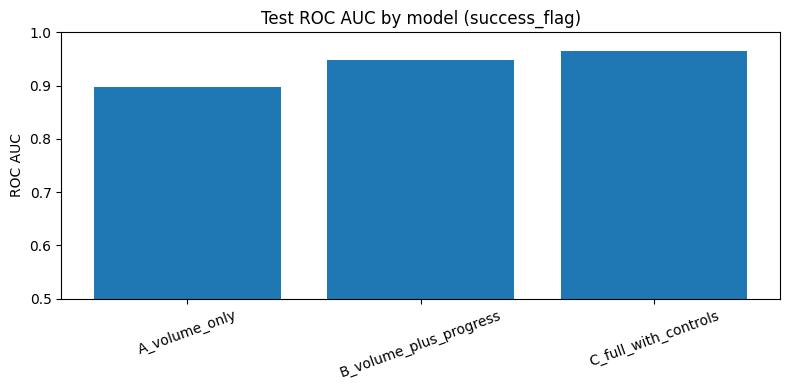

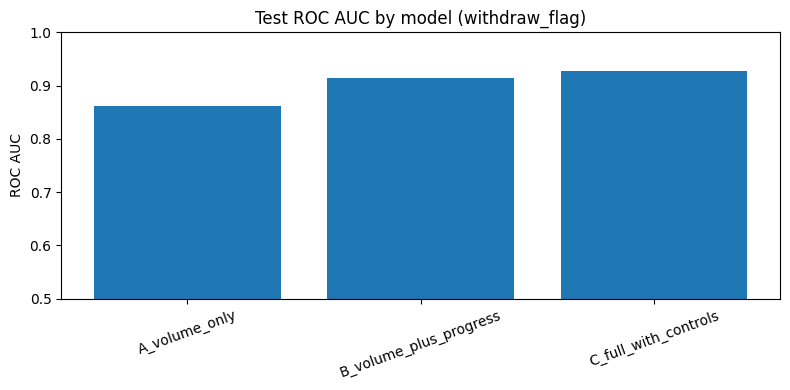

In [20]:
#Robustness check

volume_features = [
    "log_total_clicks",
    "active_days",
    "engagement_intensity"
]

progress_features = [
    "avg_score",
    "num_assess_attempted",
    "assessment_density",
    "unique_resources"
]

control_numeric = [
    "num_of_prev_attempts",
    "studied_credits"
]

control_categorical = [
    "highest_education",
    "age_band",
    "imd_band",
    "disability",
    "gender",
    "region",
    "code_module",
    "code_presentation"
]

def run_model_comparison(data, target_col):
    feature_sets = {
        "A_volume_only": volume_features,
        "B_volume_plus_progress": volume_features + progress_features,
        "C_full_with_controls": volume_features + progress_features + control_numeric + control_categorical,
    }

    results = []

    for model_name, feats in feature_sets.items():
        temp = data[feats + [target_col]].copy()

        X = temp.drop(columns=[target_col])
        y = temp[target_col]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )

        num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = [c for c in X.columns if c not in num_cols]

        numeric_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])

        preprocessor = ColumnTransformer([
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols)
        ])

        model = Pipeline([
            ("preprocessor", preprocessor),
            ("logreg", LogisticRegression(max_iter=2000))
        ])

        model.fit(X_train, y_train)

        train_pred = model.predict_proba(X_train)[:, 1]
        test_pred = model.predict_proba(X_test)[:, 1]

        results.append({
            "target": target_col,
            "model": model_name,
            "n_features_raw": len(feats),
            "n_numeric_features": len(num_cols),
            "n_categorical_features": len(cat_cols),
            "train_auc": round(roc_auc_score(y_train, train_pred), 4),
            "test_auc": round(roc_auc_score(y_test, test_pred), 4)
        })

    return pd.DataFrame(results)

success_results = run_model_comparison(df, "success_flag")
withdraw_results = run_model_comparison(df, "withdraw_flag")
model_results = pd.concat([success_results, withdraw_results], ignore_index=True)

def add_improvements(results_df):
    out = results_df.copy()
    out["delta_vs_A"] = np.nan
    out["delta_vs_B"] = np.nan

    for target in out["target"].unique():
        subset = out[out["target"] == target].set_index("model")
        auc_a = subset.loc["A_volume_only", "test_auc"]
        auc_b = subset.loc["B_volume_plus_progress", "test_auc"]
        auc_c = subset.loc["C_full_with_controls", "test_auc"]

        out.loc[(out["target"] == target) & (out["model"] == "B_volume_plus_progress"), "delta_vs_A"] = round(auc_b - auc_a, 4)
        out.loc[(out["target"] == target) & (out["model"] == "C_full_with_controls"), "delta_vs_A"] = round(auc_c - auc_a, 4)
        out.loc[(out["target"] == target) & (out["model"] == "C_full_with_controls"), "delta_vs_B"] = round(auc_c - auc_b, 4)

    return out

model_results = add_improvements(model_results)
display(model_results)

for target in model_results["target"].unique():
    temp = model_results[model_results["target"] == target].copy()

    plt.figure(figsize=(8, 4))
    plt.bar(temp["model"], temp["test_auc"])
    plt.title(f"Test ROC AUC by model ({target})")
    plt.ylabel("ROC AUC")
    plt.xticks(rotation=20)
    plt.ylim(0.5, 1.0)
    save_fig(f"model_comparison_{target}.png")
    plt.show()

model_results.to_csv("model_comparison_results.csv", index=False)

## Финальные выводы

На этом этапе у меня уже есть три основных результата:

1. сравнение отдельных метрик;
2. сегментация пользователей по volume и progress;
3. проверка через простые модели.

Теперь хочу собрать это в короткую итоговую историю: что именно получилось, какой здесь главный вывод и почему это вообще важно с продуктовой точки зрения.

Key findings:


,finding,value
0,Volume-only model performance on success,0.897
1,Volume+progress model performance on success,0.949
2,Increment from progress features on success,0.051
3,Volume-only model performance on withdrawal,0.862
4,Volume+progress model performance on withdrawal,0.914
5,Increment from progress features on withdrawal,0.052
6,High volume / High progress success rate,0.859
7,Low volume / High progress success rate,0.716
8,High volume / Low progress success rate,0.433
9,Low volume / Low progress success rate,0.037


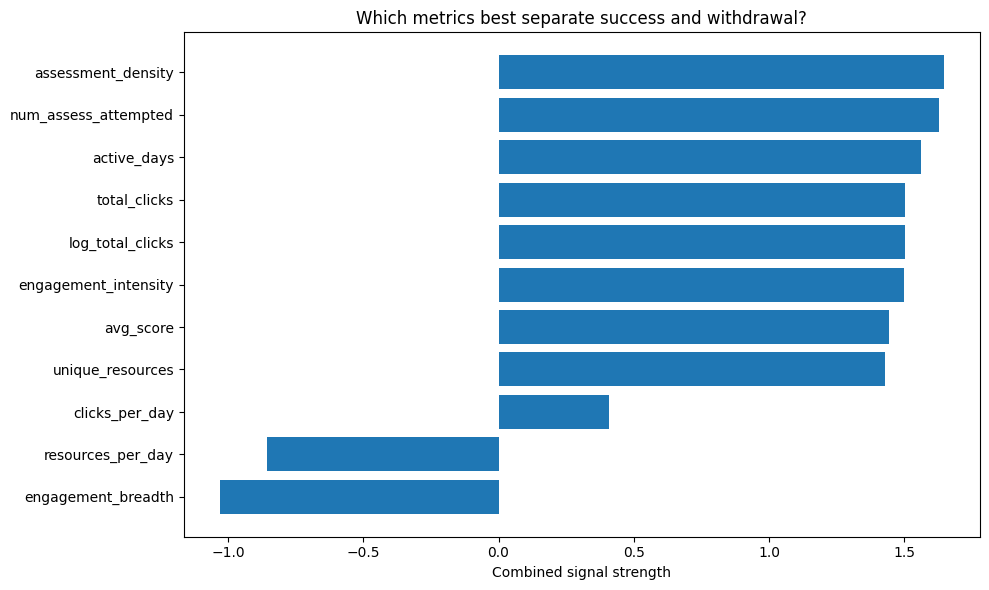

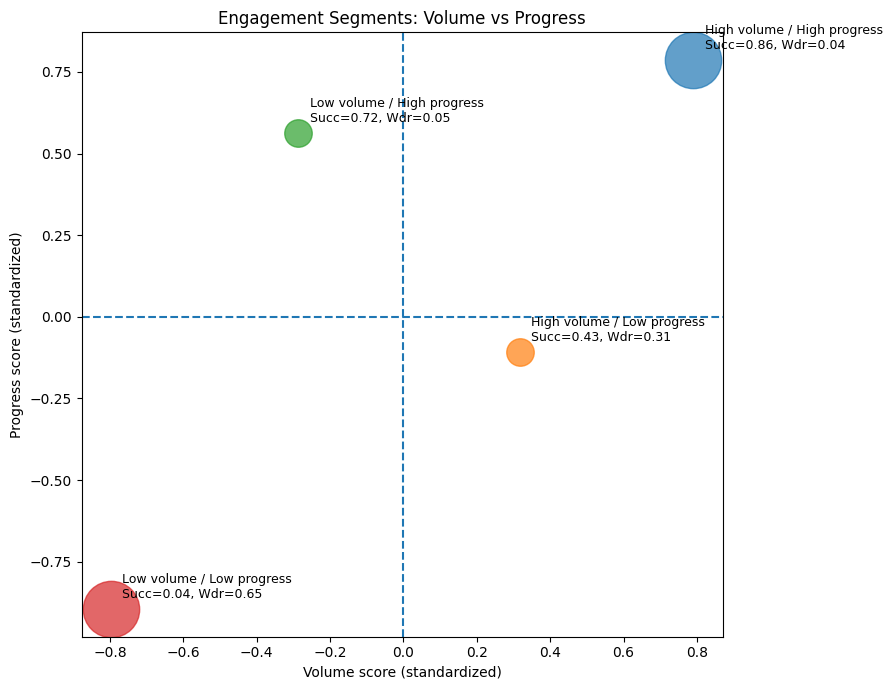

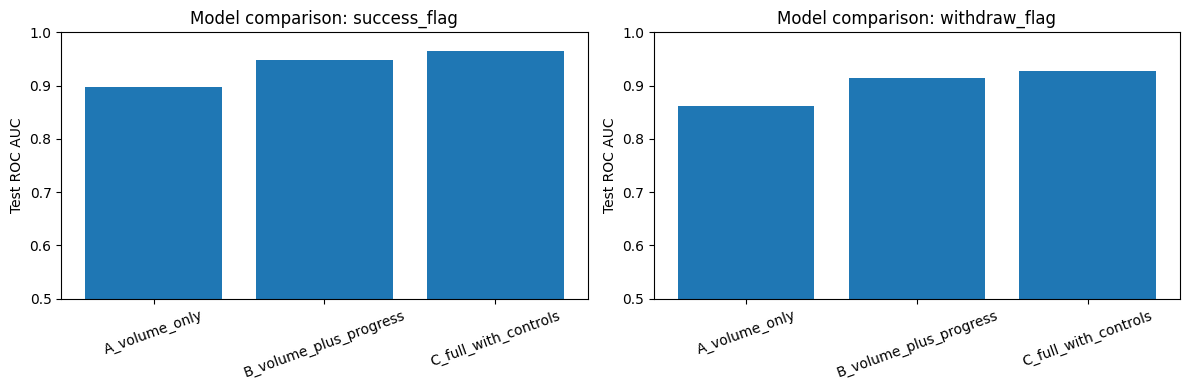

Slide table:


,engagement_segment,n_users,success_rate,withdraw_rate,median_clicks,median_active_days,median_avg_score,median_assess
0,High volume / High progress,13164,0.859,0.035,"1,791.000",94.000,80.875,9.000
1,Low volume / High progress,3133,0.716,0.053,362.000,29.000,77.571,9.000
2,High volume / Low progress,3133,0.433,0.310,"1,126.000",59.000,67.000,4.000
3,Low volume / Low progress,13163,0.037,0.650,84.000,7.000,0.000,0.000



EXECUTIVE SUMMARY

1. Простая активность уже дает полезный сигнал, но ее недостаточно.
   Для success AUC вырастает с 0.897 до 0.949 (+0.051),
   если добавить progress-метрики.
   Для withdrawal AUC вырастает с 0.862 до 0.914 (+0.052).

2. Прогресс важнее одного только объема активности.
   Low volume / High progress: success_rate = 0.716, withdrawal_rate = 0.053
   High volume / Low progress: success_rate = 0.433, withdrawal_rate = 0.310

3. Самый здоровый сегмент:
   High volume / High progress
   success_rate = 0.859, withdrawal_rate = 0.035

4. Самый рискованный сегмент:
   Low volume / Low progress
   success_rate = 0.037, withdrawal_rate = 0.650

5. Практический вывод:
   В таком продукте нельзя считать usage volume достаточной метрикой здоровья пользователя.
   Метрики прогресса намного лучше отражают meaningful engagement.

Saved:
- final_key_findings.csv
- final_slide_table.csv
- executive_summary.txt


In [21]:
#Final outputs

#Собираем ключевые числа в одну таблицу
key_findings = pd.DataFrame({
    "finding": [
        "Volume-only model performance on success",
        "Volume+progress model performance on success",
        "Increment from progress features on success",
        "Volume-only model performance on withdrawal",
        "Volume+progress model performance on withdrawal",
        "Increment from progress features on withdrawal",
        "High volume / High progress success rate",
        "Low volume / High progress success rate",
        "High volume / Low progress success rate",
        "Low volume / Low progress success rate",
        "High volume / High progress withdrawal rate",
        "Low volume / High progress withdrawal rate",
        "High volume / Low progress withdrawal rate",
        "Low volume / Low progress withdrawal rate"
    ],
    "value": [
        float(model_results.query("target == 'success_flag' and model == 'A_volume_only'")["test_auc"].iloc[0]),
        float(model_results.query("target == 'success_flag' and model == 'B_volume_plus_progress'")["test_auc"].iloc[0]),
        float(model_results.query("target == 'success_flag' and model == 'B_volume_plus_progress'")["delta_vs_A"].iloc[0]),

        float(model_results.query("target == 'withdraw_flag' and model == 'A_volume_only'")["test_auc"].iloc[0]),
        float(model_results.query("target == 'withdraw_flag' and model == 'B_volume_plus_progress'")["test_auc"].iloc[0]),
        float(model_results.query("target == 'withdraw_flag' and model == 'B_volume_plus_progress'")["delta_vs_A"].iloc[0]),

        float(segment_summary.loc["High volume / High progress", "success_rate"]),
        float(segment_summary.loc["Low volume / High progress", "success_rate"]),
        float(segment_summary.loc["High volume / Low progress", "success_rate"]),
        float(segment_summary.loc["Low volume / Low progress", "success_rate"]),

        float(segment_summary.loc["High volume / High progress", "withdraw_rate"]),
        float(segment_summary.loc["Low volume / High progress", "withdraw_rate"]),
        float(segment_summary.loc["High volume / Low progress", "withdraw_rate"]),
        float(segment_summary.loc["Low volume / Low progress", "withdraw_rate"])
    ]
})

print("Key findings:")
display(key_findings)

#Финальный график №1: ranking метрик
metric_strength_plot = metric_strength.sort_values("combined_signal_strength", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(metric_strength_plot["metric"], metric_strength_plot["combined_signal_strength"])
plt.title("Which metrics best separate success and withdrawal?")
plt.xlabel("Combined signal strength")
save_fig("final_metric_strength_ranking.png")
plt.show()

#Финальный график №2: сегменты volume vs progress
plt.figure(figsize=(9, 7))
for _, row in segment_points.iterrows():
    plt.scatter(row["x"], row["y"], s=row["n_users"] / 8, alpha=0.7)
    plt.annotate(
        f'{row["engagement_segment"]}\nSucc={row["success_rate"]:.2f}, Wdr={row["withdraw_rate"]:.2f}',
        (row["x"], row["y"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9
    )
plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")
plt.title("Engagement Segments: Volume vs Progress")
plt.xlabel("Volume score (standardized)")
plt.ylabel("Progress score (standardized)")
save_fig("final_engagement_segments.png")
plt.show()

#Финальный график №3: сравнение моделей
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, target in zip(axes, ["success_flag", "withdraw_flag"]):
    temp = model_results[model_results["target"] == target].copy()
    ax.bar(temp["model"], temp["test_auc"])
    ax.set_title(f"Model comparison: {target}")
    ax.set_ylabel("Test ROC AUC")
    ax.set_ylim(0.5, 1.0)
    ax.tick_params(axis="x", rotation=20)

save_fig("final_model_comparison.png")
plt.show()

slide_table = (
    segment_summary
    .reset_index()[[
        "engagement_segment",
        "n_users",
        "success_rate",
        "withdraw_rate",
        "median_clicks",
        "median_active_days",
        "median_avg_score",
        "median_assess"
    ]]
    .round(3)
)

print("Slide table:")
display(slide_table)

#Удобно заранее достать ключевые числа
success_auc_a = model_results.query("target == 'success_flag' and model == 'A_volume_only'")["test_auc"].iloc[0]
success_auc_b = model_results.query("target == 'success_flag' and model == 'B_volume_plus_progress'")["test_auc"].iloc[0]
success_delta = model_results.query("target == 'success_flag' and model == 'B_volume_plus_progress'")["delta_vs_A"].iloc[0]

withdraw_auc_a = model_results.query("target == 'withdraw_flag' and model == 'A_volume_only'")["test_auc"].iloc[0]
withdraw_auc_b = model_results.query("target == 'withdraw_flag' and model == 'B_volume_plus_progress'")["test_auc"].iloc[0]
withdraw_delta = model_results.query("target == 'withdraw_flag' and model == 'B_volume_plus_progress'")["delta_vs_A"].iloc[0]

hv_hp_success = segment_summary.loc["High volume / High progress", "success_rate"]
lv_hp_success = segment_summary.loc["Low volume / High progress", "success_rate"]
hv_lp_success = segment_summary.loc["High volume / Low progress", "success_rate"]
lv_lp_success = segment_summary.loc["Low volume / Low progress", "success_rate"]

hv_hp_withdraw = segment_summary.loc["High volume / High progress", "withdraw_rate"]
lv_hp_withdraw = segment_summary.loc["Low volume / High progress", "withdraw_rate"]
hv_lp_withdraw = segment_summary.loc["High volume / Low progress", "withdraw_rate"]
lv_lp_withdraw = segment_summary.loc["Low volume / Low progress", "withdraw_rate"]


summary_text = f"""
EXECUTIVE SUMMARY

1. Простая активность уже дает полезный сигнал, но ее недостаточно.
   Для success AUC вырастает с {success_auc_a:.3f} до {success_auc_b:.3f} (+{success_delta:.3f}),
   если добавить progress-метрики.
   Для withdrawal AUC вырастает с {withdraw_auc_a:.3f} до {withdraw_auc_b:.3f} (+{withdraw_delta:.3f}).

2. Прогресс важнее одного только объема активности.
   Low volume / High progress: success_rate = {lv_hp_success:.3f}, withdrawal_rate = {lv_hp_withdraw:.3f}
   High volume / Low progress: success_rate = {hv_lp_success:.3f}, withdrawal_rate = {hv_lp_withdraw:.3f}

3. Самый здоровый сегмент:
   High volume / High progress
   success_rate = {hv_hp_success:.3f}, withdrawal_rate = {hv_hp_withdraw:.3f}

4. Самый рискованный сегмент:
   Low volume / Low progress
   success_rate = {lv_lp_success:.3f}, withdrawal_rate = {lv_lp_withdraw:.3f}

5. Практический вывод:
   В таком продукте нельзя считать usage volume достаточной метрикой здоровья пользователя.
   Метрики прогресса намного лучше отражают meaningful engagement.
"""

print(summary_text)

key_findings.to_csv("final_key_findings.csv", index=False)
slide_table.to_csv("final_slide_table.csv", index=False)

with open("executive_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved:")
print("- final_key_findings.csv")
print("- final_slide_table.csv")
print("- executive_summary.txt")

## Итог

Главный вывод у меня получился такой: активность сама по себе полезна как сигнал, но она явно не равна осмысленной вовлеченности.

В этом датасете метрики прогресса объясняют успех и риск ухода заметно лучше, чем один только объем использования. Самый показательный результат — это сегменты, где пользователи с меньшей активностью, но с высоким прогрессом, выглядят лучше, чем пользователи с высокой активностью, но слабым прогрессом.

Для продукта это важный вывод, потому что он показывает, что ориентироваться только на usage volume опасно. Такие метрики легко переоценить, хотя они не всегда отражают реальное движение пользователя к результату.

Отдельно важно, что я здесь не пытаюсь доказывать причинность. Часть progress-метрик уже довольно близка к самому outcome, поэтому этот проект лучше трактовать как сравнение двух способов измерять вовлеченность: через простой usage volume и через более осмысленные сигналы прогресса.